# Homework Assignment 4: Data Visualization
## F&W ECOL 458: Environmental Data Science

**[Ines Lopez-Silvero]**

**Total Points:** 100

**Instructions:**
- Complete all three problems in this notebook
- Write your code in the provided cells
- Run all cells to verify your code works and figures display correctly
- Save your completed `.ipynb` file to the `homework` folder in your private GitHub repository (shared with the instructor)
- Submit the link to your notebook on Canvas

**⚠️ IMPORTANT:** GitHub records the timestamp of every file update. Your notebook must be committed to GitHub **before the deadline**. **DO NOT** update the file after the deadline—late modifications will be flagged and may not be accepted.

**Academic Integrity:** This is an individual assignment. You may consult course materials, Python documentation, AI tools, and discuss concepts with classmates, but all code must be your own.

---

In [ ]:
# Standard imports - run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Problem 1: Visualizing Climate Data (35 points)

You have monthly climate data from a weather station. Create visualizations to explore temperature and precipitation patterns.

### Your Tasks:

**Part A (15 points):** Create a **line plot** showing monthly average temperature for both years on the same axes.
- Use different colors and line styles for each year
- Add markers to show individual data points
- Include a horizontal dashed line showing the overall mean temperature (across both years)
- Add proper axis labels (with units), title, legend, and grid
- Use month names (J, F, M, ...) instead of numbers on the x-axis

**Part B (20 points):** Create a **grouped bar chart** comparing monthly precipitation between the two years.
- Place bars for 2023 and 2024 side by side for each month
- Use appropriate colors and add a legend
- Add axis labels (with units) and a title
- Add value labels on top of each bar showing the precipitation amount

In [15]:
# Climate data
import pandas as pd
import matplotlib.pyplot as plt
climate_data = pd.DataFrame({
    'month': range(1, 13),
    'month_name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'temp_2023': [-6.2, -4.1, 1.8, 9.5, 15.2, 20.8, 23.5, 22.1, 17.3, 10.2, 3.1, -3.5],
    'temp_2024': [-5.1, -2.8, 3.2, 10.8, 16.5, 22.1, 25.2, 23.8, 18.5, 11.5, 4.2, -2.1],
    'precip_2023': [32, 28, 45, 72, 95, 102, 88, 76, 68, 55, 42, 38],
    'precip_2024': [28, 35, 52, 68, 88, 115, 95, 82, 72, 48, 38, 42]
})

climate_data

,month,month_name,temp_2023,temp_2024,precip_2023,precip_2024
0,1,Jan,-6.2,-5.1,32,28
1,2,Feb,-4.1,-2.8,28,35
2,3,Mar,1.8,3.2,45,52
3,4,Apr,9.5,10.8,72,68
4,5,May,15.2,16.5,95,88
5,6,Jun,20.8,22.1,102,115
6,7,Jul,23.5,25.2,88,95
7,8,Aug,22.1,23.8,76,82
8,9,Sep,17.3,18.5,68,72
9,10,Oct,10.2,11.5,55,48


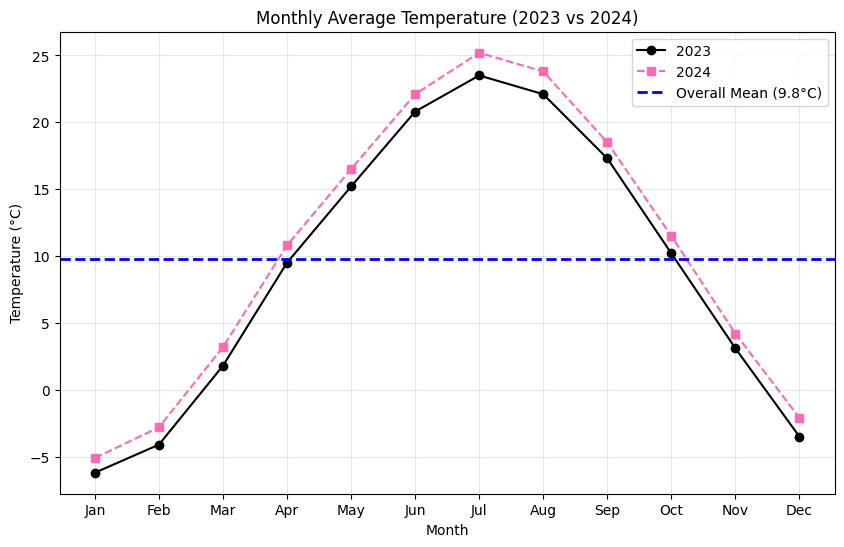

In [16]:
# Part A: Line plot of temperature
months = climate_data['month_name']
temp_2023 = climate_data['temp_2023']
temp_2024 = climate_data['temp_2024']
overall_mean_temp = (temp_2023.mean() + temp_2024.mean()) / 2

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(months, temp_2023, 'o-', label='2023', color='black') # Changed color for clarity
ax.plot(months, temp_2024, 's--', label='2024', color='hotpink') # Changed color and linestyle for clarity
ax.axhline(y=overall_mean_temp, color='blue', linestyle='--', linewidth=2, label=f'Overall Mean ({overall_mean_temp:.1f}°C)')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Monthly Average Temperature (2023 vs 2024)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig('climate_analysis.png',dpi=300)
plt.show()

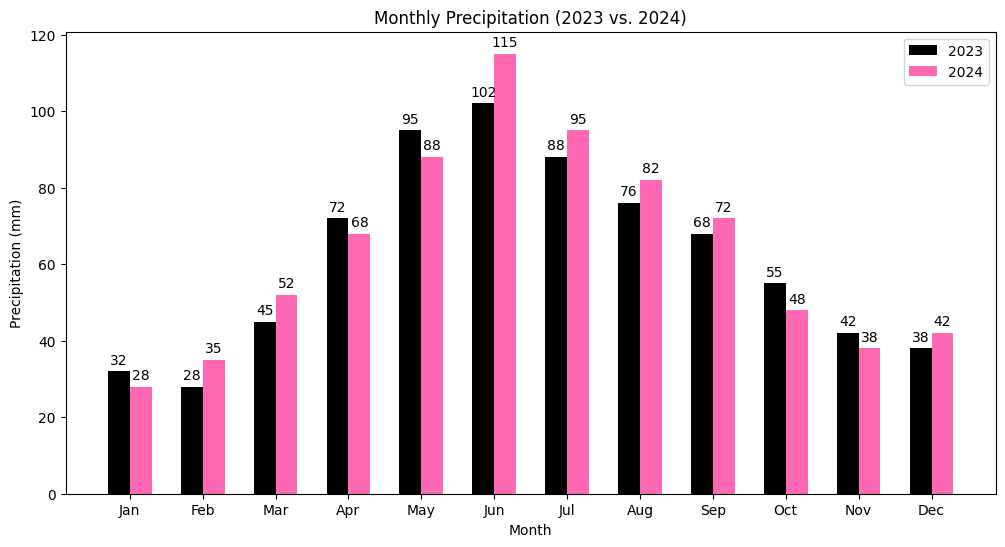

In [17]:
# Part B: Grouped bar chart of precipitation
import numpy as np # Added this import
fig, ax=plt.subplots(figsize=(12,6))
x=np.arange(len(months)) # Fixed typo: arrange to arange
width=0.3 # Width of each bar
bar_offset = width/2 # Offset for grouped bars

# Plotting bars for 2023 and 2024
rects2023 = ax.bar(x - bar_offset, climate_data['precip_2023'], width, label='2023', color='black')
rects2024 = ax.bar(x + bar_offset, climate_data['precip_2024'], width, label='2024', color='hotpink')

ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Monthly Precipitation (2023 vs. 2024)') # Fixed title spacing
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels(months)

# Add value labels on top of each bar
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', # Display integer values for precipitation
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects2023)
autolabel(rects2024)

plt.savefig('climate_analysis.png',dpi=300)
plt.show()

---
## Problem 2: Exploring Species Distributions (35 points)

You have measurement data from a bird survey across three habitat types. Use visualizations to explore the data.

### Your Tasks:

**Part A (15 points):** Create a **single figure with 1 row and 3 columns** showing histograms of `wing_length_mm` for each habitat type separately.
- Use a different color for each habitat
- Use shared y-axis (`sharey=True`) so distributions are comparable
- Add a main title for the entire figure using `plt.suptitle()`
- Add axis labels to each subplot

**Part B (20 points):** Create a **single figure with 1 row and 2 columns**:
- **Left panel:** A Seaborn violin plot comparing `body_mass_g` across habitat types
- **Right panel:** A Seaborn scatter plot of `wing_length_mm` vs `body_mass_g`, colored by `habitat`, with a regression line for the entire dataset (hint: use `sns.regplot` first, then `sns.scatterplot` with `hue`)
- Add proper labels and titles to both panels
- Save the figure as `bird_analysis.png` with 300 dpi

In [11]:
# Bird survey data
np.random.seed(458)
n_per_habitat = 50

bird_data = pd.DataFrame({
    'habitat': np.repeat(['Forest', 'Wetland', 'Grassland'], n_per_habitat),
    'wing_length_mm': np.concatenate([
        np.random.normal(85, 8, n_per_habitat),   # Forest
        np.random.normal(92, 10, n_per_habitat),  # Wetland
        np.random.normal(78, 7, n_per_habitat)    # Grassland
    ]),
    'body_mass_g': np.concatenate([
        np.random.normal(28, 4, n_per_habitat),   # Forest
        np.random.normal(35, 6, n_per_habitat),   # Wetland
        np.random.normal(24, 3, n_per_habitat)    # Grassland
    ])
})

bird_data.head()

,habitat,wing_length_mm,body_mass_g
0,Forest,81.927461,23.185356
1,Forest,80.536893,22.835132
2,Forest,80.362027,28.452494
3,Forest,97.862415,27.982051
4,Forest,98.177658,32.304888


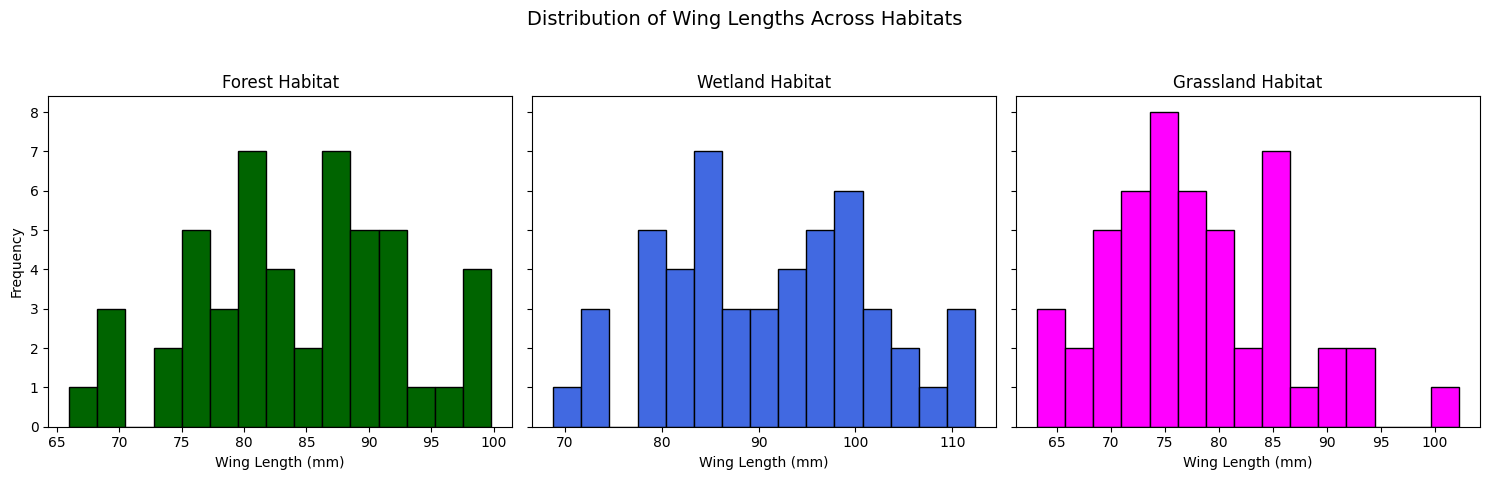

In [14]:
# Part A: Three histograms in subplots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig, ax=plt.subplots(1, 3, figsize=(15,5), sharey=True)
colors=['darkgreen','royalblue','magenta']
habitats=['Forest','Wetland','Grassland']
for i,habitat in enumerate(habitats):
  subset= bird_data[bird_data['habitat']==habitat]
  ax[i].hist(subset['wing_length_mm'],bins=15,color=colors[i],edgecolor='black')

  ax[i].set_title(f'{habitat} Habitat')
  ax[i].set_xlabel('Wing Length (mm)')
  if i==0:
    ax[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Wing Lengths Across Habitats',fontsize=14)
plt.tight_layout(rect=[0,0.03,1,0.95])

plt.savefig('bird_analysis.png',dpi=300)
plt.show()




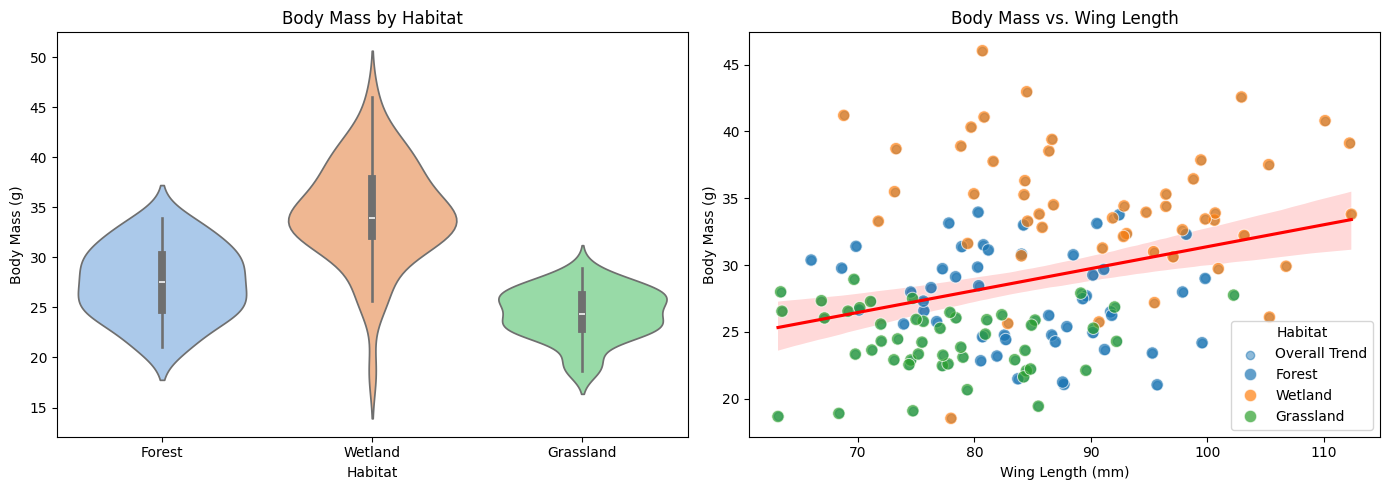

In [13]:
# Part B: Violin plot and scatter plot with regression
import seaborn as sns
fig, axes=plt.subplots(1,2,figsize=(14,5))
sns.violinplot(data=bird_data, x='habitat', y='body_mass_g',hue='habitat',palette='pastel',ax=axes[0])
axes[0].set_title('Body Mass by Habitat')
axes[0].set_xlabel('Habitat')
axes[0].set_ylabel('Body Mass (g)')

sns.regplot(data=bird_data,x='wing_length_mm', y='body_mass_g', scatter_kws={'alpha':0.5},line_kws={'color':'red'},ax=axes[1],label='Overall Trend') # Corrected 'aplha' to 'alpha'
sns.scatterplot(data=bird_data,x='wing_length_mm',y='body_mass_g',hue='habitat',ax=axes[1],s=80,alpha=0.7)
axes[1].set_title('Body Mass vs. Wing Length')
axes[1].set_xlabel('Wing Length (mm)')
axes[1].set_ylabel('Body Mass (g)')
axes[1].legend(title='Habitat')

plt.tight_layout()
plt.savefig('bird_analysis.png',dpi=300)
plt.show()

---
## Problem 3: Water Quality Dashboard (30 points)

Create a comprehensive 2×2 multi-panel figure summarizing water quality data from a lake monitoring program.

### Your Task:

Create a **single figure with 4 panels (2 rows × 2 columns)** containing:

1. **Top-left:** Line plot of `chlorophyll_ug_l` over `date` (shows algae concentration over time)
   - Add a horizontal line at 10 µg/L (EPA threshold for concern)
   - Shade the region above 10 µg/L in light red (by adjusting the level of transparency)

2. **Top-right:** Seaborn box plot comparing `dissolved_oxygen_mg_l` across `month` (use month numbers 5-9)

3. **Bottom-left:** Scatter plot of `temperature_c` vs `dissolved_oxygen_mg_l`
   - Color points by `chlorophyll_ug_l` using a colormap
   - Add a colorbar

4. **Bottom-right:** Histogram of `secchi_depth_m` (water clarity) with a vertical line showing the mean

**Requirements:**
- Use `figsize=(14, 10)` for the figure
- Add appropriate axis labels (with units) and titles to all panels
- Use `plt.tight_layout()` to prevent overlap
- Save as `water_quality_dashboard.png` with 300 dpi

In [4]:
# Lake monitoring data (May - September 2024)
import pandas as pd
import numpy as np

np.random.seed(123)

dates = pd.date_range('2024-05-01', '2024-09-30', freq='D')
n_days = len(dates)

# Temperature increases through summer then decreases
day_of_period = np.arange(n_days)
temp_pattern = 18 + 8 * np.sin(np.pi * day_of_period / n_days)

lake_data = pd.DataFrame({
    'date': dates,
    'month': dates.month,
    'temperature_c': temp_pattern + np.random.normal(0, 1.5, n_days),
    'dissolved_oxygen_mg_l': 12 - 0.3 * temp_pattern + np.random.normal(0, 1, n_days),
    'chlorophyll_ug_l': 5 + 0.4 * temp_pattern + np.random.exponential(2, n_days),
    'secchi_depth_m': np.random.normal(3.5, 0.8, n_days).clip(min=0.5)
})

# Ensure DO stays positive
lake_data['dissolved_oxygen_mg_l'] = lake_data['dissolved_oxygen_mg_l'].clip(lower=2)

lake_data.head()

,date,month,temperature_c,dissolved_oxygen_mg_l,chlorophyll_ug_l,secchi_depth_m
0,2024-05-01,5,16.371554,4.723131,15.226135,3.531924
1,2024-05-02,5,19.660273,5.531069,12.807950,3.632816
2,2024-05-03,5,18.752908,6.669410,13.140048,3.637571
3,2024-05-04,5,16.233045,7.006110,18.542097,3.123518
4,2024-05-05,5,17.788426,5.872427,14.607339,2.720625


/tmp/ipython-input-2094/2089919347.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lake_data, x='month', y='dissolved_oxygen_mg_l', ax=axes[0,1],palette='pink')


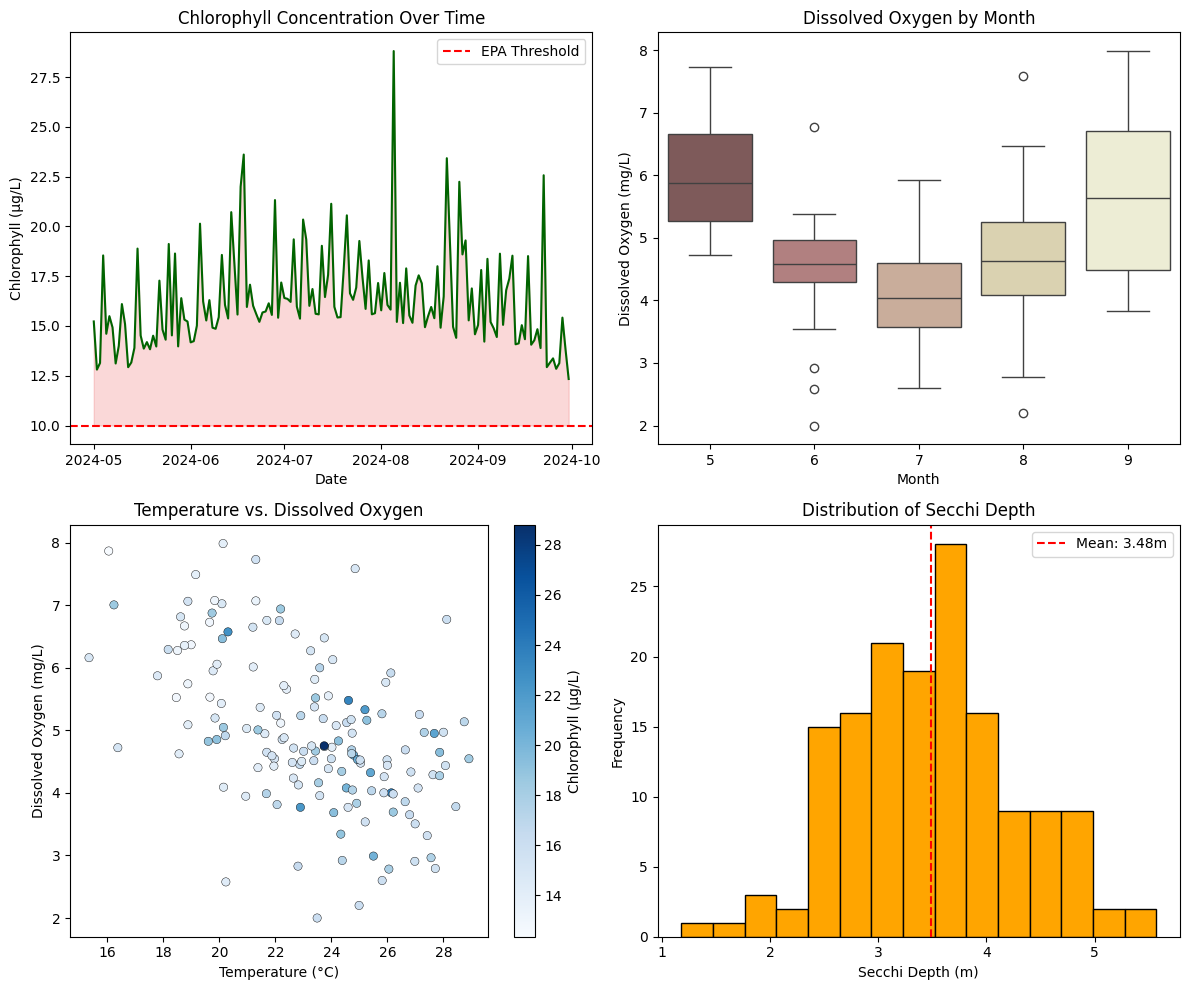

In [8]:
# Create the 2x2 dashboard
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes=plt.subplots(2,2,figsize=(12,10))
axes[0,0].plot(lake_data['date'],lake_data['chlorophyll_ug_l'],color='darkgreen')
axes[0,0].axhline(y=10,color='red',linestyle='--',label='EPA Threshold')
axes[0,0].fill_between(lake_data['date'],lake_data['chlorophyll_ug_l'],10, where=(lake_data['chlorophyll_ug_l']>10),color='lightcoral',alpha=0.3)
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Chlorophyll (µg/L)')
axes[0,0].set_title('Chlorophyll Concentration Over Time')
axes[0,0].legend()

sns.boxplot(data=lake_data, x='month', y='dissolved_oxygen_mg_l', ax=axes[0,1],palette='pink')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Dissolved Oxygen (mg/L)')
axes[0,1].set_title('Dissolved Oxygen by Month')

scatter= axes[1,0].scatter(lake_data['temperature_c'], lake_data['dissolved_oxygen_mg_l'],c=lake_data['chlorophyll_ug_l'],cmap='Blues',edgecolor='black',linewidths=0.3)
cbar=plt.colorbar(scatter,ax=axes[1,0])
cbar.set_label('Chlorophyll (µg/L)')
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Dissolved Oxygen (mg/L)')
axes[1,0].set_title('Temperature vs. Dissolved Oxygen')

axes[1,1].hist(lake_data['secchi_depth_m'],bins=15,color='orange',edgecolor='black')
secchi_mean=lake_data['secchi_depth_m'].mean()
axes[1,1].axvline(x=secchi_mean,color='red',linestyle='--',label=f'Mean: {secchi_mean:.2f}m')
axes[1,1].set_xlabel('Secchi Depth (m)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Secchi Depth')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('water_quality_dashboard.png',dpi=300)
plt.show()





---
## Submission Checklist

Before submitting, verify that:

- [ ] All code cells run without errors
- [ ] All three problems are complete
- [ ] All figures display correctly
- [ ] Figures are saved as PNG files (`bird_analysis.png`, `water_quality_dashboard.png`)
- [ ] Your name is filled
- [ ] File is saved to the `homework` folder in your private GitHub repository
- [ ] File is committed and pushed **before the deadline**
- [ ] Link to your notebook is submitted on Canvas